## Example the correction result

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def show_distribution_log_scale(array, title):
	fig, ax = plt.subplots(figsize=(8, 4))
	ax.hist(array.ravel(), bins=1000, color='gray')
	ax.set_title(title)
	ax.set_xlabel('Pixel Intensity')
	ax.set_ylabel('Frequency')
	ax.set_yscale('log')
	ax.grid(False)
	plt.show()

def img_show(array, title):
	# Calculate mean along each axis
	mean_x_axis = np.mean(array, axis=0) # Mean along columns
	mean_y_axis = np.mean(array, axis=1) # Mean along rows

	# Create subplots
	fig, ax = plt.subplots(1, 3, figsize=(12, 4)) # One row, three columns

	# Plot the image
	im = ax[0].imshow(array, cmap='rainbow') # Display image in 'rainbow' colormap
	ax[0].set_title('Original Image')
	ax[0].set_xlabel('X-axis (Columns)')
	ax[0].set_ylabel('Y-axis (Rows)')
	fig.colorbar(im, ax=ax[0], orientation='vertical', label='Intensity')


	# Plot the mean along the X-axis
	ax[1].plot(mean_x_axis)
	ax[1].set_title('Mean along X-axis')
	ax[1].set_xlabel('X-axis (Columns)')
	ax[1].set_ylabel('Mean Intensity')

	# Plot the mean along the Y-axis
	ax[2].plot(mean_y_axis, range(len(mean_y_axis))) # Plot against y-axis indices
	ax[2].set_title('Mean along Y-axis')
	ax[2].set_xlabel('Mean Intensity')
	ax[2].set_ylabel('Y-axis (Rows)')
	ax[2].invert_yaxis() # Invert y-axis to match image orientation

	plt.suptitle(title, fontsize=16)
	plt.tight_layout()
	plt.show()




## correction algorithm

In [13]:
def estimate_gain_org(array_this, array_correction):
    eps = 1e-12
    denom = np.sum((array_this * array_correction) ** 2) + eps
    numer = np.sum(array_this * array_correction) * 50000.0
    return numer / denom

def estimate_gain(array_this, array_correction):
    eps = 1e-12
    
    # Compute element-wise products
    products = array_this * array_correction
    
    # Flatten to 1D for processing
    flat_products = products.flatten()
    
    if len(flat_products) == 0:
        return 0.0  # Return 0 for empty arrays
    
    # Get absolute values and sort them in descending order
    abs_products = np.abs(flat_products)
    sorted_indices = np.argsort(abs_products)[::-1]  # Sort in descending order
    
    # Take the first half (largest elements)
    n_elements = len(flat_products)
    n_full_intensity = max(1, n_elements // 2)  # Ensure at least 1 element
    n_too_big_outliers = n_elements // 10
    
    # Get indices of the largest half elements
    largest_indices = sorted_indices[n_too_big_outliers:n_full_intensity]
    
    # Extract the largest half elements
    filtered_products = flat_products[largest_indices]
    
    # Compute gain
    denom = np.sum(filtered_products ** 2) + eps
    numer = np.sum(filtered_products) * 50000.0
    
    return numer / denom



def correct_image(array_this, array_correction):
    gain = estimate_gain(array_this, array_correction)
    array_corrected = array_this * array_correction * gain
    return array_corrected

## Show the correction array

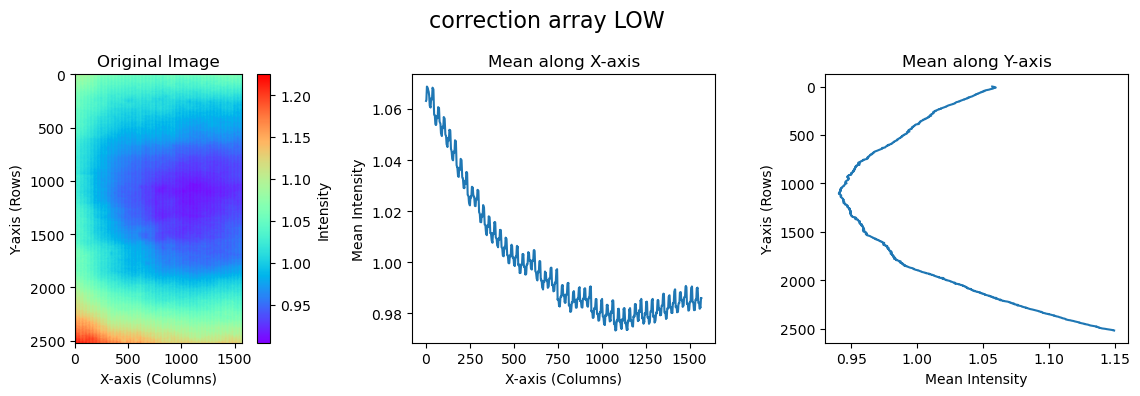

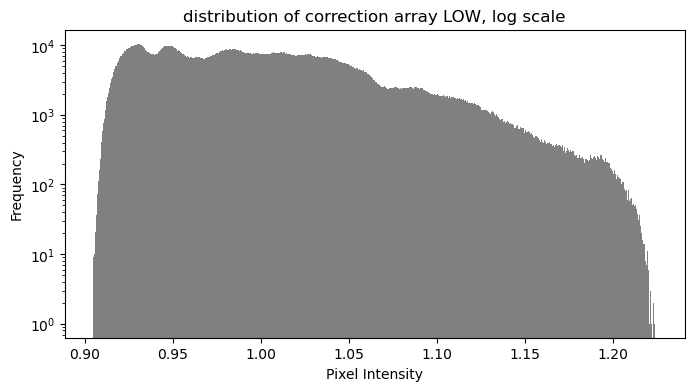

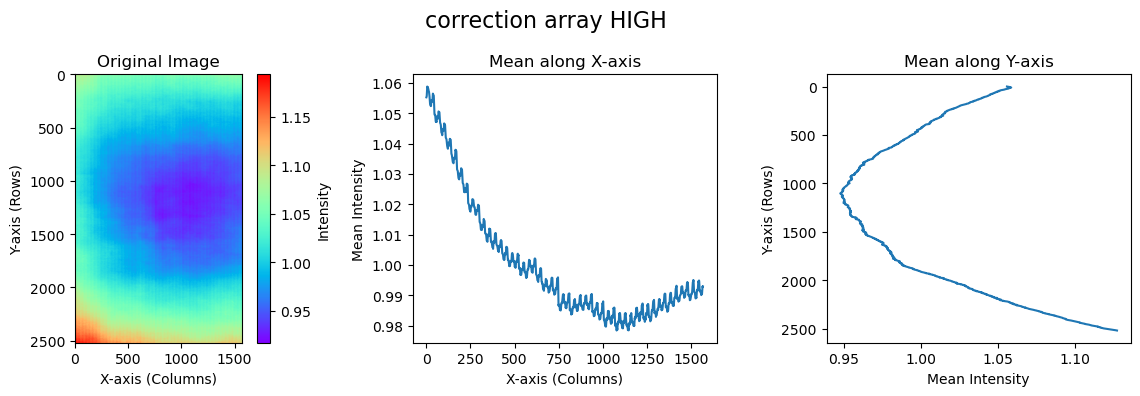

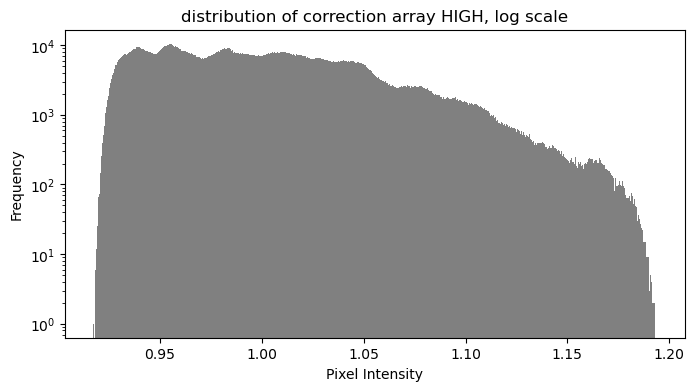

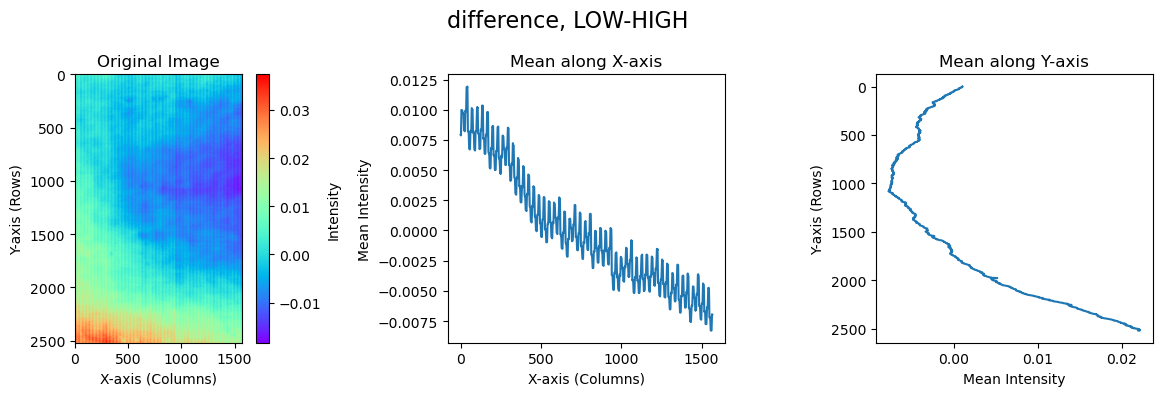

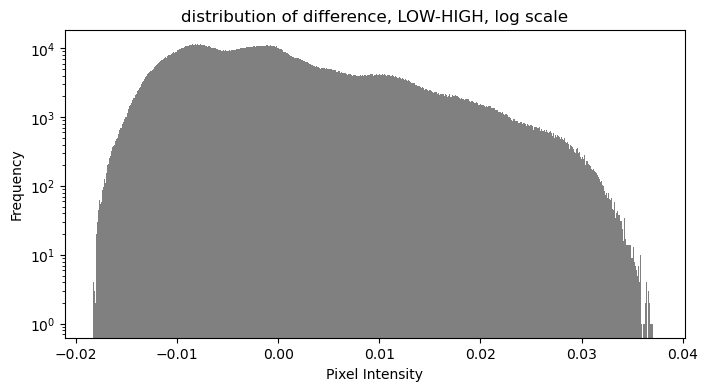

In [14]:
IMAGE_HEIGHT = 2560 - 20 - 20
IMAGE_WIDTH = 2048 - 20 - 460

array_correction_low = np.loadtxt("output/correction_low.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
array_correction_high = np.loadtxt("output/correction_high.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_correction_low, "correction array LOW")
show_distribution_log_scale(array_correction_low, "distribution of correction array LOW, log scale")
img_show(array_correction_high, "correction array HIGH")
show_distribution_log_scale(array_correction_high, "distribution of correction array HIGH, log scale")

array_difference = array_correction_low - array_correction_high
img_show(array_difference, "difference, LOW-HIGH")
show_distribution_log_scale(array_difference, "distribution of difference, LOW-HIGH, log scale")


## Show example corrected image

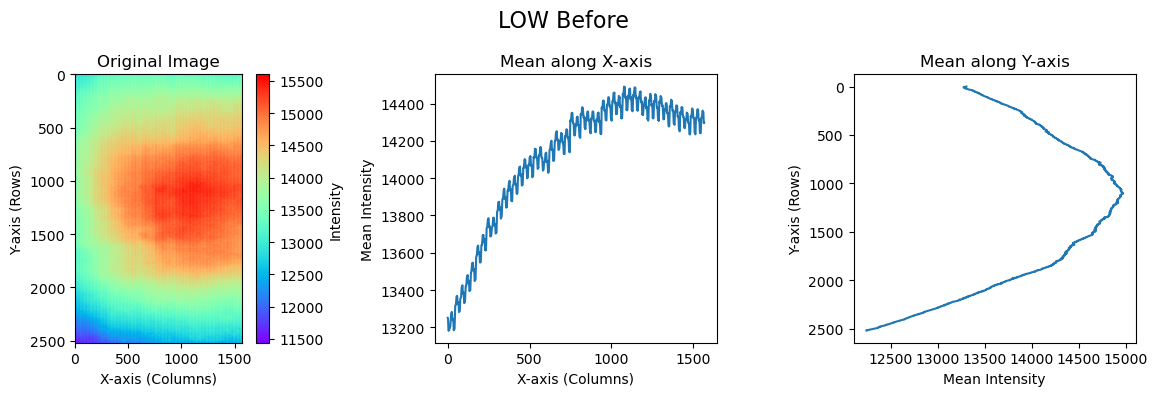

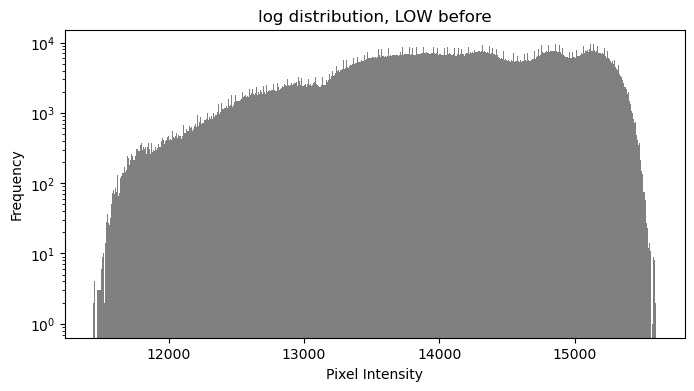

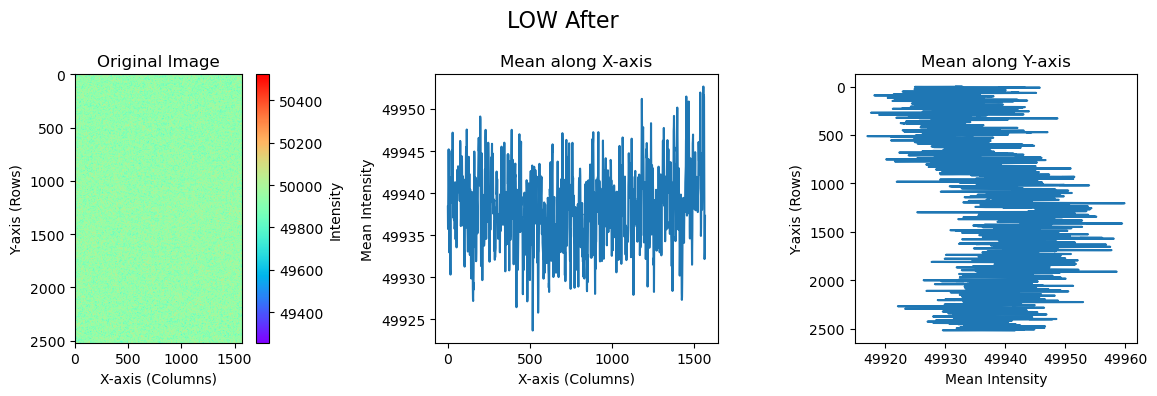

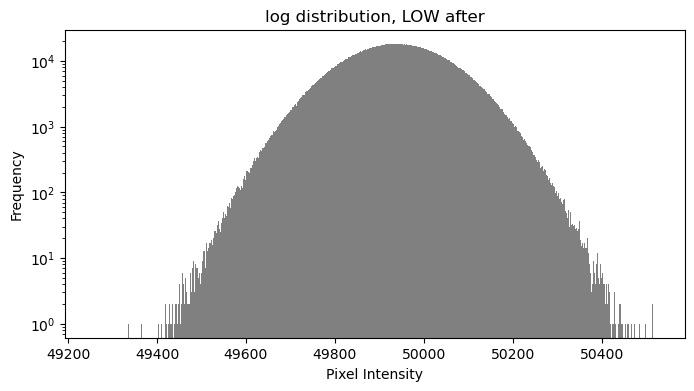

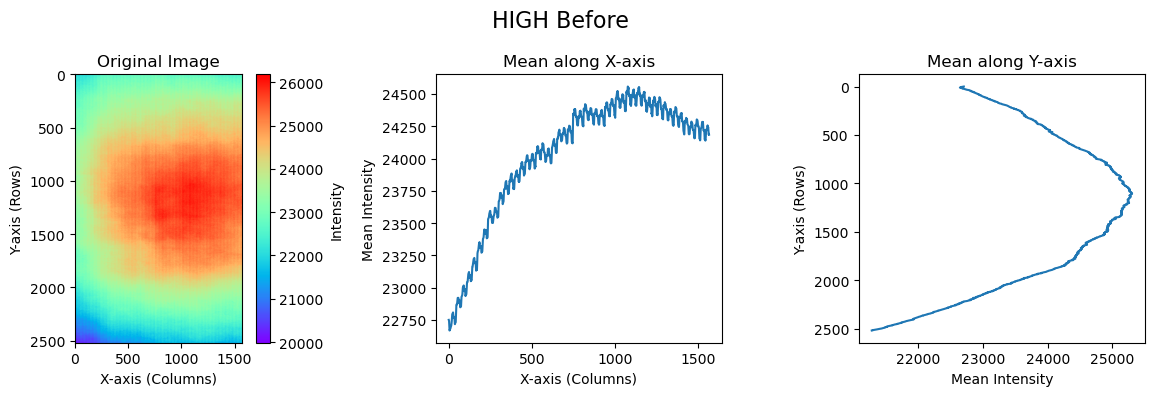

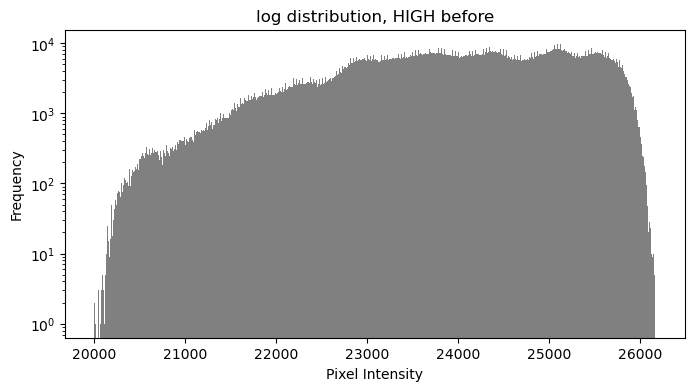

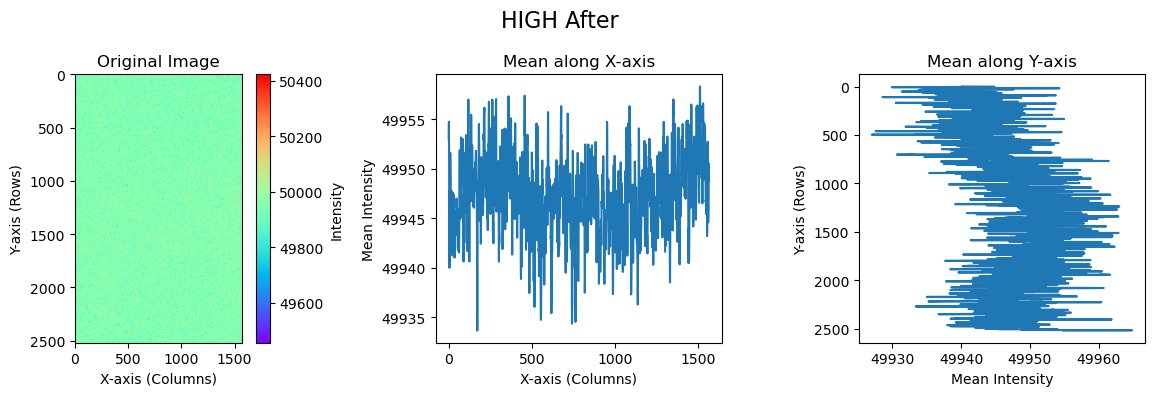

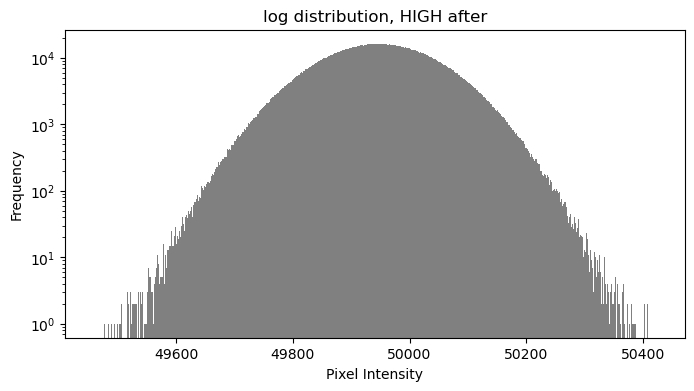

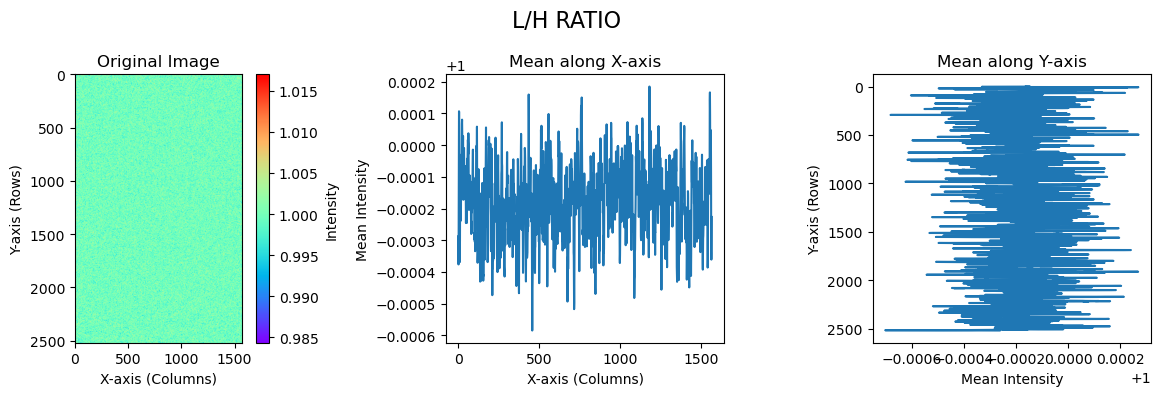

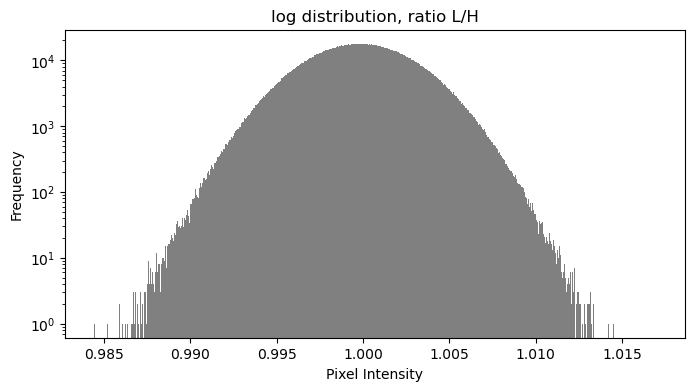

In [15]:

sample = "39"

raw_file_low = f"output/empty/{sample}.raw.low"
raw_file_high = f"output/empty/{sample}.raw.high"

array_low_before = np.fromfile(raw_file_low, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_low_before, "LOW Before")
show_distribution_log_scale(array_low_before, "log distribution, LOW before")

array_low_after = correct_image(array_low_before, array_correction_low)

img_show(array_low_after, "LOW After")
show_distribution_log_scale(array_low_after, "log distribution, LOW after")

array_high_before = np.fromfile(raw_file_high, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_high_before, "HIGH Before")
show_distribution_log_scale(array_high_before, "log distribution, HIGH before")

array_high_after = correct_image(array_high_before, array_correction_high)

img_show(array_high_after, "HIGH After")
show_distribution_log_scale(array_high_after, "log distribution, HIGH after")

array_ratio_low_over_high = array_low_after / array_high_after

img_show(array_ratio_low_over_high, "L/H RATIO")
show_distribution_log_scale(array_ratio_low_over_high, "log distribution, ratio L/H")


## Jensen Shannon Distance

In [18]:
from jensen_shannon_distance import jensen_shannon_distance_of_two_images

def build_filename_pairs(filename_prefix, filename_suffix):
    list_compare = []
    count_image = 110
    for n1 in range(100, count_image):
        filename1 = f"{filename_prefix}{n1}{filename_suffix}"
        for n2 in range(n1 + 1, count_image):
            filename2 = f"{filename_prefix}{n2}{filename_suffix}"
            list_compare.append((filename1, filename2))
    
    return list_compare

list_compare_low_off  = build_filename_pairs("output/empty/",    ".raw.low")
list_compare_high_off = build_filename_pairs("output/empty/",    ".raw.high")
list_compare_low_cor  = build_filename_pairs("output/empty/",    ".raw.low.cor")
list_compare_high_cor = build_filename_pairs("output/empty/",    ".raw.high.cor")
list_compare_low_on   = build_filename_pairs("output/empty/on/", ".raw.low")
list_compare_high_on  = build_filename_pairs("output/empty/on/", ".raw.high")

import multiprocessing

pool = multiprocessing.Pool()

list_distance_low_off = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_off)
print(f"Mean distance for LOW  OFF   = {np.mean(list_distance_low_off):.6f},  std={np.std(list_distance_low_off):.6f}")

list_distance_low_cor = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_cor)
print(f"Mean distance for LOW  COR   = {np.mean(list_distance_low_cor):.6f},  std={np.std(list_distance_low_cor):.6f}")

list_distance_low_on = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_on)
print(f"Mean distance for LOW  ON    = {np.mean(list_distance_low_on):.6f},  std={np.std(list_distance_low_on):.6f}")

list_distance_high_off = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_off)
print(f"Mean distance for HIGH OFF   = {np.mean(list_distance_high_off):.6f},  std={np.std(list_distance_high_off):.6f}")

list_distance_high_cor = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_cor)
print(f"Mean distance for HIGH COR   = {np.mean(list_distance_high_cor):.6f},  std={np.std(list_distance_high_cor):.6f}")

list_distance_high_on = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_on)
print(f"Mean distance for HIGH ON    = {np.mean(list_distance_high_on):.6f},  std={np.std(list_distance_high_on):.6f}")

pool.close()
pool.join()



Mean distance for LOW  OFF   = 0.027237,  std=0.001075
Mean distance for LOW  COR   = 0.014284,  std=0.000191
Mean distance for LOW  ON    = 0.026118,  std=0.012144
Mean distance for HIGH OFF   = 0.033108,  std=0.000855
Mean distance for HIGH COR   = 0.013998,  std=0.000202
Mean distance for HIGH ON    = 0.025318,  std=0.010006
